In [119]:
!pip install -q kaggle

In [120]:
import os
os.environ['KAGGLE_USERNAME'] = 'Alsafaalwahshi'
os.environ['KAGGLE_KEY'] = '5979421017ecc7f111a476fdc743b829'

In [121]:
!kaggle datasets download -d zeynepdemirta/ciciomt2024-attacks

Dataset URL: https://www.kaggle.com/datasets/zeynepdemirta/ciciomt2024-attacks
License(s): unknown
ciciomt2024-attacks.zip: Skipping, found more recently modified local copy (use --force to force download)


In [122]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
!unzip ciciomt2024-attacks.zip -d /content/drive/MyDrive/

Archive:  ciciomt2024-attacks.zip
replace /content/drive/MyDrive/csv/test/ARP_Spoofing_test.pcap.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/drive/MyDrive/csv/test/ARP_Spoofing_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/Benign_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/MQTT-DDoS-Connect_Flood_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/MQTT-DDoS-Publish_Flood_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/MQTT-DoS-Connect_Flood_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/MQTT-DoS-Publish_Flood_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/MQTT-Malformed_Data_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/Recon-OS_Scan_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/Recon-Ping_Sweep_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/Recon-Port_Scan_test.pcap.csv  
  inflating: /content/drive/MyDrive/csv/test/Recon-VulScan_test.pca

In [124]:
!pip install -q scikit-learn

In [125]:
import pandas as pd # reading csv file
import numpy as np # working with mathmatical operations
import os #for files
import joblib

from sklearn import metrics
import matplotlib.pyplot as plt # draing graphs

from sklearn.preprocessing import LabelEncoder #preprocessing DS
from sklearn.model_selection import train_test_split #splitting
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #evaluation
from sklearn import tree #visualize tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler #scaling
from sklearn.decomposition import PCA #PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [126]:
!ls /content/drive/MyDrive/csv

test  train


In [127]:
train_path ='/content/drive/MyDrive/csv/train'
train_files = os.listdir(train_path)
train_list = [] #empty list

for file in train_files:
  if file.endswith('.csv'):
    file_path = os.path.join(train_path,file)
    temp_df = pd.read_csv(file_path) #temporary container for ONE file
    temp_df['label'] = 'Benign' if 'benign' in file.lower() else 'Attack'
    train_list.append(temp_df)

train_df = pd.concat(train_list, ignore_index=True)
print("train shape :", train_df.shape)


train shape : (7160831, 46)


In [128]:
test_path ='/content/drive/MyDrive/csv/test'
test_files = os.listdir(test_path)
test_list = []

for file in test_files:
  if file.endswith('.csv'):
    file_path = os.path.join(test_path,file)
    temp_df = pd.read_csv(file_path) #temporary container for ONE file
    temp_df['label'] = 'Benign' if 'benign' in file.lower() else 'Attack'
    test_list.append(temp_df)

test_df = pd.concat(test_list, ignore_index=True)
print("test shape :", test_df.shape)

test shape : (1614182, 46)


In [129]:
train_df = train_df.sample(n=200000, random_state=42)
test_df = test_df.sample(n=200000, random_state=42)

print(train_df.shape)
print(test_df.shape)

(200000, 46)
(200000, 46)


In [130]:
train_df.head()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
1623710,0.00,1.0,64.0,140.994487,140.994487,0.0,0.0,0.00,0.00,0.0,...,0.000000,42.00,8.469708e+07,9.5,9.165151,0.000000,0.00000,0.00,141.55,Attack
3424305,54.00,6.0,64.0,142179.796610,142179.796610,0.0,0.0,0.00,0.00,0.0,...,0.000000,54.00,8.469612e+07,9.5,10.392305,0.000000,0.00000,0.00,141.55,Attack
6062837,83.38,6.0,64.0,5.619925,5.619925,0.0,0.0,0.92,0.08,0.0,...,0.238279,56.44,8.467473e+07,9.5,10.632867,0.337281,0.32063,0.19,141.55,Attack
5701101,0.00,1.0,64.0,1.330901,1.330901,0.0,0.0,0.00,0.00,0.0,...,0.000000,42.00,8.467928e+07,9.5,9.165151,0.000000,0.00000,0.00,141.55,Attack
1225404,0.00,1.0,64.0,277.591382,277.591382,0.0,0.0,0.00,0.00,0.0,...,0.000000,42.00,8.469704e+07,9.5,9.165151,0.000000,0.00000,0.00,141.55,Attack


In [131]:
train_df.describe()

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,2.000000e+05,200000.000000,200000.000000,2.000000e+05,2.000000e+05,200000.0,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2.926060e+04,8.052325,64.726278,1.522999e+04,1.522999e+04,0.0,0.004954,0.159725,0.039126,0.022444,...,60.694132,6.320951,60.699989,8.467157e+07,9.498608,10.445491,8.929187,2508.440660,0.091328,141.514603
std,2.740180e+05,6.294325,8.368370,3.974397e+04,3.974397e+04,0.0,0.033538,0.339599,0.137813,0.097616,...,87.075641,38.613941,86.834195,1.783703e+07,0.842342,3.135654,54.590460,20252.454586,0.232468,21.686001
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,...,42.000000,0.000000,42.000000,0.000000e+00,1.000000,9.165151,0.000000,0.000000,0.000000,1.000000
25%,5.400000e+01,1.160000,64.000000,6.658611e+00,6.658611e+00,0.0,0.000000,0.000000,0.000000,0.000000,...,42.335160,0.000000,42.580000,8.467888e+07,9.500000,9.200478,0.000000,0.000000,0.000000,141.550000
50%,1.080000e+02,6.000000,64.000000,1.456757e+02,1.456757e+02,0.0,0.000000,0.000000,0.000000,0.000000,...,50.000000,0.000000,50.000000,8.469641e+07,9.500000,10.000000,0.000000,0.000000,0.000000,141.550000
75%,1.971650e+04,17.000000,64.000000,1.915984e+04,1.915984e+04,0.0,0.000000,0.000000,0.000000,0.000000,...,54.000000,0.000000,54.000000,8.469686e+07,9.500000,10.392305,0.000000,0.000000,0.000000,141.550000
max,9.737523e+06,17.000000,255.000000,2.097152e+06,2.097152e+06,0.0,0.840000,1.000000,1.000000,1.000000,...,1514.000000,713.240276,1514.000000,1.694694e+08,13.500000,55.027266,1009.043098,509122.746068,1.000000,244.600000


In [132]:
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())

label
Attack    194644
Benign      5356
Name: count, dtype: int64
label
Attack    195392
Benign      4608
Name: count, dtype: int64


In [133]:
def pie_plot(df, col):
  plt.figure(figsize=(5,5))
  df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#ff66b2'])

  plt.title(f'{col} distribution')
  plt.show()

train distribution before balancing:


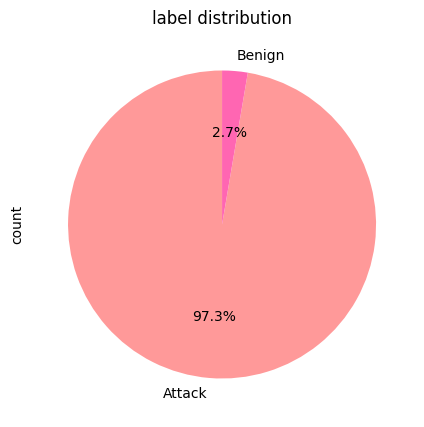

In [134]:
#visualize before sampling

print('train distribution before balancing:')

pie_plot(train_df, 'label')

In [135]:
benign_df = train_df[train_df['label'] == 'Benign']
attack_df = train_df[train_df['label'] == 'Attack']

print(len(benign_df))
print(len(attack_df))

min_size = len(benign_df)

attack_Sample = attack_df.sample(n=min_size, random_state=42)

train_df = pd.concat([benign_df, attack_Sample])
train_df = train_df.sample(frac=1, random_state=42)

print("After balancing:")
print(train_df['label'].value_counts())


5356
194644
After balancing:
label
Attack    5356
Benign    5356
Name: count, dtype: int64


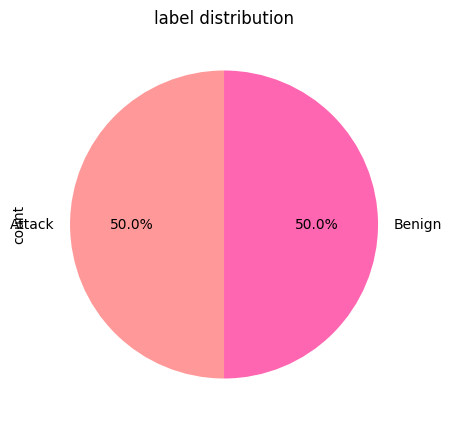

In [136]:
pie_plot(train_df, 'label')

In [137]:
#encode labels (convert words to numbers)
le = LabelEncoder() # create object
train_df['label'] = le.fit_transform(train_df['label'])
test_df['label'] = le.transform(test_df['label'])

print(train_df['label'].value_counts())


label
0    5356
1    5356
Name: count, dtype: int64


In [138]:
x_train = train_df.drop(columns=['label'], axis=1)
x_train = x_train.select_dtypes(include=['int64', 'float64'])

y_train = train_df['label']

x_test = test_df.drop(columns=['label'], axis=1)
x_test = x_test.select_dtypes(include=['int64', 'float64'])

y_test = test_df['label']

x_train, x_test = x_train.align(x_test, join='inner', axis=1)



In [139]:
feature_names = x_train.columns
print(feature_names)

Index(['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight'],
      dtype='object')


In [140]:

#normalize features
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns) #learn mean and sd of training data
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns) #apply scaling



In [141]:
train_df.to_csv('/content/drive/MyDrive/train_df.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/test_df.csv', index=False)

In [142]:
#reduce number of features
pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train) # learn
x_test_pca = pca.transform(x_test) #apply

In [143]:
selector = SelectKBest(f_classif, k=20)
x_train_selected = selector.fit_transform(x_train, y_train)
x_test_selected = selector.transform(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 5 12] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [144]:
selected_features = x_train.columns[selector.get_support()]
print(selected_features)

Index(['Header_Length', 'Rate', 'Srate', 'syn_flag_number', 'psh_flag_number',
       'ack_flag_number', 'rst_count', 'HTTPS', 'TCP', 'UDP', 'ICMP',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'Magnitue', 'Radius',
       'Variance'],
      dtype='object')


In [145]:
# creating decisionTree

tree_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, class_weight={0:1, 1:1.5}, random_state=42).fit(x_train, y_train)
tree_pca = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, class_weight={0:1, 1:1.5}, random_state=42).fit(x_train_pca, y_train)
tree_fs = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, class_weight={0:1, 1:1.5}, random_state=42).fit(x_train_selected, y_train)

In [146]:
model_results={}

In [147]:
def evaluate_classification(model, model_name, x_train, x_test, y_train, y_test):
  y_train_pred = model.predict(x_train)
  y_test_pred = model.predict(x_test)

  train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
  test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

  train_precision = metrics.precision_score(y_train, y_train_pred)
  test_precision = metrics.precision_score(y_test, y_test_pred)

  train_recall = metrics.recall_score(y_train, y_train_pred)
  test_recall = metrics.recall_score(y_test, y_test_pred)

  train_f1 = metrics.f1_score(y_train, y_train_pred)
  test_f1 = metrics.f1_score(y_test, y_test_pred)

  model_results[model_name] =[train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall, train_f1, test_f1]

  print(f"\n{model_name}")
  print(f"Train Accuracy: {train_accuracy:.4f}")
  print(f"Test Accuracy: {test_accuracy:.4f}")
  print(f"Train Precision: {train_precision:.4f}")
  print(f"Test Precision: {test_precision:.4f}")
  print(f"Train Recall: {train_recall:.4f}")
  print(f"Test Recall: {test_recall:.4f}")
  print(f"Train F1 Score: {train_f1:.4f}")
  print(f"Test F1 Score: {test_f1:.4f}")

  print("\nClassification Report:")
  print(metrics.classification_report(y_test, y_test_pred))

  cm = metrics.confusion_matrix(y_test, y_test_pred)
  disp = metrics.ConfusionMatrixDisplay(cm,display_labels=['Attack', 'Benign'])
  disp.plot()
  plt.title(f"{model_name}")
  plt.show()


decision tree (depth=10)
Train Accuracy: 0.9941
Test Accuracy: 0.9880
Train Precision: 0.9905
Test Precision: 0.6586
Train Recall: 0.9978
Test Recall: 0.9980
Train F1 Score: 0.9941
Test F1 Score: 0.7935

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    195392
           1       0.66      1.00      0.79      4608

    accuracy                           0.99    200000
   macro avg       0.83      0.99      0.89    200000
weighted avg       0.99      0.99      0.99    200000



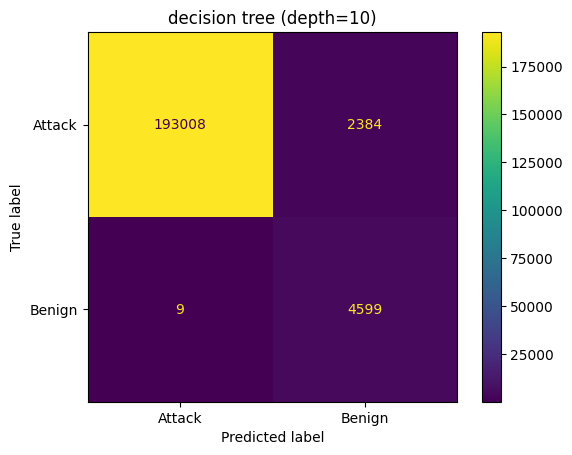


decision tree (depth=10) with PCA
Train Accuracy: 0.9938
Test Accuracy: 0.9872
Train Precision: 0.9927
Test Precision: 0.6452
Train Recall: 0.9950
Test Recall: 0.9907
Train F1 Score: 0.9938
Test F1 Score: 0.7815

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    195392
           1       0.65      0.99      0.78      4608

    accuracy                           0.99    200000
   macro avg       0.82      0.99      0.89    200000
weighted avg       0.99      0.99      0.99    200000



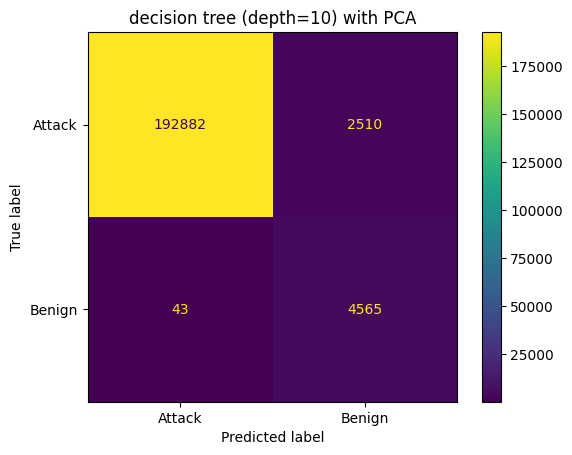


decision tree (depth=10) with feature selection
Train Accuracy: 0.9925
Test Accuracy: 0.9877
Train Precision: 0.9880
Test Precision: 0.6523
Train Recall: 0.9972
Test Recall: 0.9970
Train F1 Score: 0.9926
Test F1 Score: 0.7886

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    195392
           1       0.65      1.00      0.79      4608

    accuracy                           0.99    200000
   macro avg       0.83      0.99      0.89    200000
weighted avg       0.99      0.99      0.99    200000



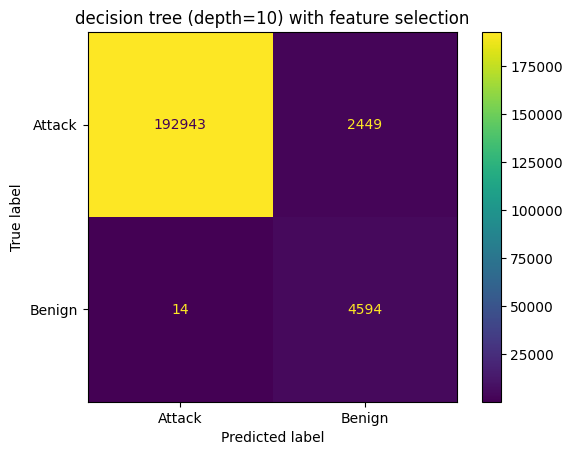

In [148]:
# evalute models

evaluate_classification(tree_model, "decision tree (depth=10)" , x_train, x_test, y_train, y_test)
evaluate_classification(tree_pca, "decision tree (depth=10) with PCA" , x_train_pca, x_test_pca, y_train, y_test)
evaluate_classification(tree_fs, "decision tree (depth=10) with feature selection" , x_train_selected, x_test_selected, y_train, y_test)

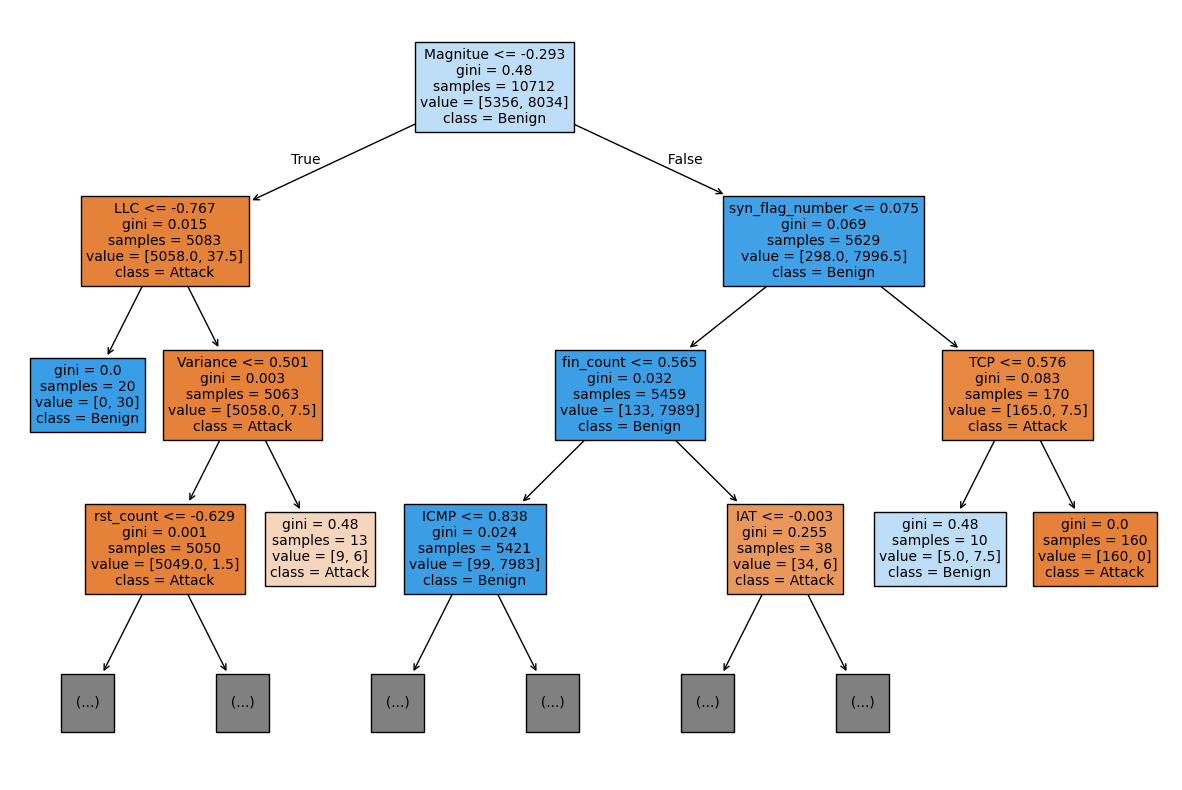

In [149]:


plt.figure(figsize=(15,10))
tree.plot_tree(
    tree_model,
    max_depth=3,
    filled=True,
    fontsize=10,
    feature_names=feature_names,
    class_names=['Attack', 'Benign']
)
plt.show()

In [150]:

#original
nb_model = GaussianNB().fit(x_train, y_train)

#PCA
nb_pca = GaussianNB().fit(x_train_pca, y_train)

#feature selection
nb_fs = GaussianNB().fit(x_train_selected, y_train)



naive bayes(original)
Train Accuracy: 0.9932
Test Accuracy: 0.9827
Train Precision: 0.9876
Test Precision: 0.5716
Train Recall: 0.9989
Test Recall: 0.9987
Train F1 Score: 0.9932
Test F1 Score: 0.7271

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.57      1.00      0.73      4608

    accuracy                           0.98    200000
   macro avg       0.79      0.99      0.86    200000
weighted avg       0.99      0.98      0.98    200000



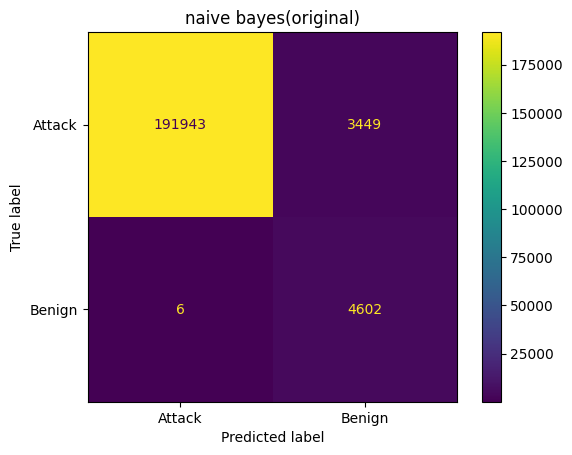


naive bayes(PCA)
Train Accuracy: 0.9824
Test Accuracy: 0.9759
Train Precision: 0.9817
Test Precision: 0.4879
Train Recall: 0.9830
Test Recall: 0.8869
Train F1 Score: 0.9824
Test F1 Score: 0.6295

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.49      0.89      0.63      4608

    accuracy                           0.98    200000
   macro avg       0.74      0.93      0.81    200000
weighted avg       0.99      0.98      0.98    200000



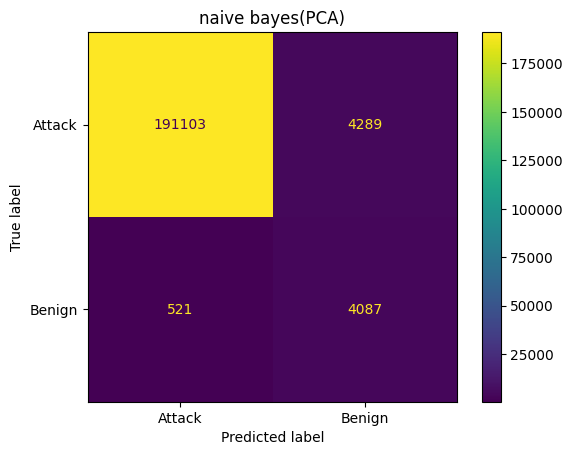


naive bayes(feature selection)
Train Accuracy: 0.9858
Test Accuracy: 0.9802
Train Precision: 0.9824
Test Precision: 0.5394
Train Recall: 0.9894
Test Recall: 0.9644
Train F1 Score: 0.9859
Test F1 Score: 0.6918

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.54      0.96      0.69      4608

    accuracy                           0.98    200000
   macro avg       0.77      0.97      0.84    200000
weighted avg       0.99      0.98      0.98    200000



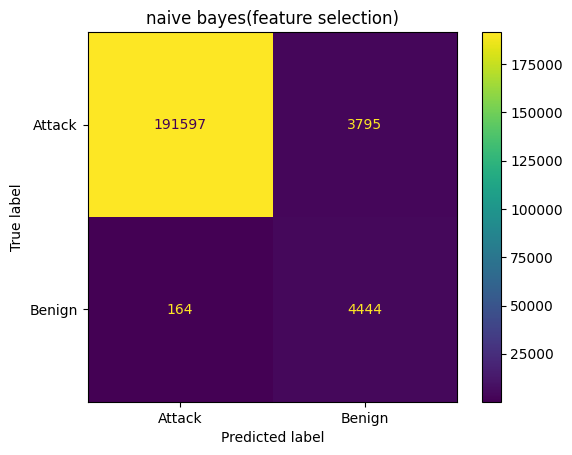

In [151]:
#original
evaluate_classification(nb_model, "naive bayes(original)", x_train, x_test, y_train, y_test)

#PCA
evaluate_classification(nb_pca, "naive bayes(PCA)", x_train_pca, x_test_pca, y_train, y_test)

#feature selection
evaluate_classification(nb_fs, "naive bayes(feature selection)", x_train_selected, x_test_selected, y_train, y_test)
#

In [152]:


#original
lr_model = LogisticRegression(max_iter=1000).fit(x_train, y_train)

#PCA
lr_pca = LogisticRegression(max_iter=1000).fit(x_train_pca, y_train)

#feature selection
lr_fs = LogisticRegression(max_iter=1000).fit(x_train_selected, y_train)



logistic regression(original)
Train Accuracy: 0.9947
Test Accuracy: 0.9850
Train Precision: 0.9909
Test Precision: 0.6063
Train Recall: 0.9985
Test Recall: 0.9987
Train F1 Score: 0.9947
Test F1 Score: 0.7545

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.61      1.00      0.75      4608

    accuracy                           0.99    200000
   macro avg       0.80      0.99      0.87    200000
weighted avg       0.99      0.99      0.99    200000



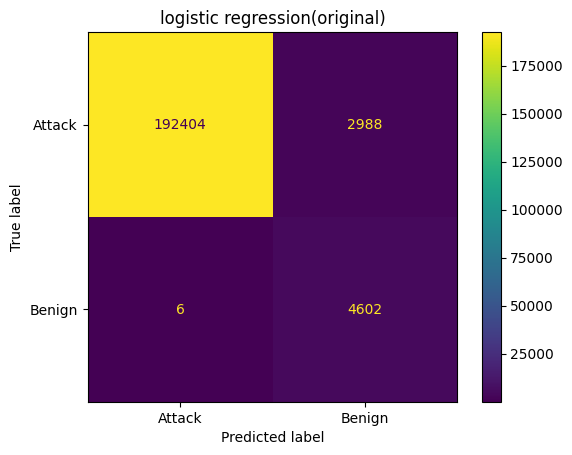


logistic regression(PCA)
Train Accuracy: 0.9909
Test Accuracy: 0.9845
Train Precision: 0.9903
Test Precision: 0.5984
Train Recall: 0.9914
Test Recall: 0.9926
Train F1 Score: 0.9909
Test F1 Score: 0.7467

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.60      0.99      0.75      4608

    accuracy                           0.98    200000
   macro avg       0.80      0.99      0.87    200000
weighted avg       0.99      0.98      0.99    200000



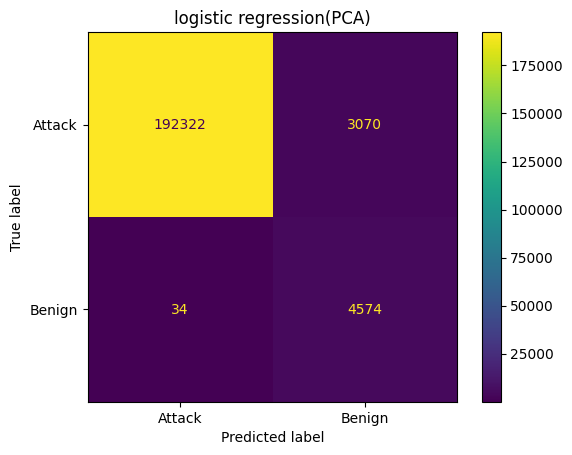


logistic regression(feature selection)
Train Accuracy: 0.9906
Test Accuracy: 0.9823
Train Precision: 0.9874
Test Precision: 0.5661
Train Recall: 0.9938
Test Recall: 0.9954
Train F1 Score: 0.9906
Test F1 Score: 0.7217

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    195392
           1       0.57      1.00      0.72      4608

    accuracy                           0.98    200000
   macro avg       0.78      0.99      0.86    200000
weighted avg       0.99      0.98      0.98    200000



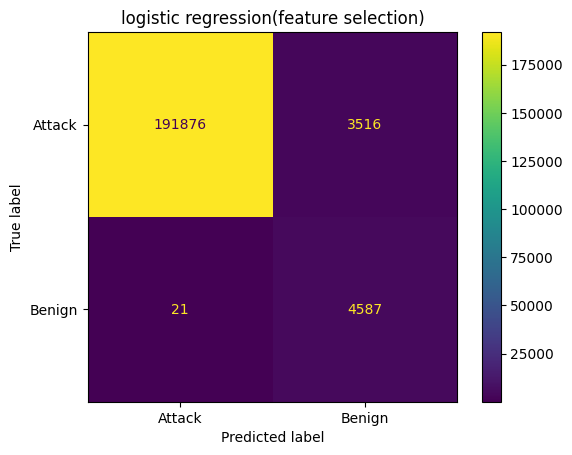

In [153]:
#original
evaluate_classification(lr_model, "logistic regression(original)", x_train, x_test, y_train, y_test)

#PCA
evaluate_classification(lr_pca, "logistic regression(PCA)", x_train_pca, x_test_pca, y_train, y_test)

#feature selection
evaluate_classification(lr_fs, "logistic regression(feature selection)", x_train_selected, x_test_selected, y_train, y_test)

In [154]:
print(model_results.keys())

dict_keys(['decision tree (depth=10)', 'decision tree (depth=10) with PCA', 'decision tree (depth=10) with feature selection', 'naive bayes(original)', 'naive bayes(PCA)', 'naive bayes(feature selection)', 'logistic regression(original)', 'logistic regression(PCA)', 'logistic regression(feature selection)'])


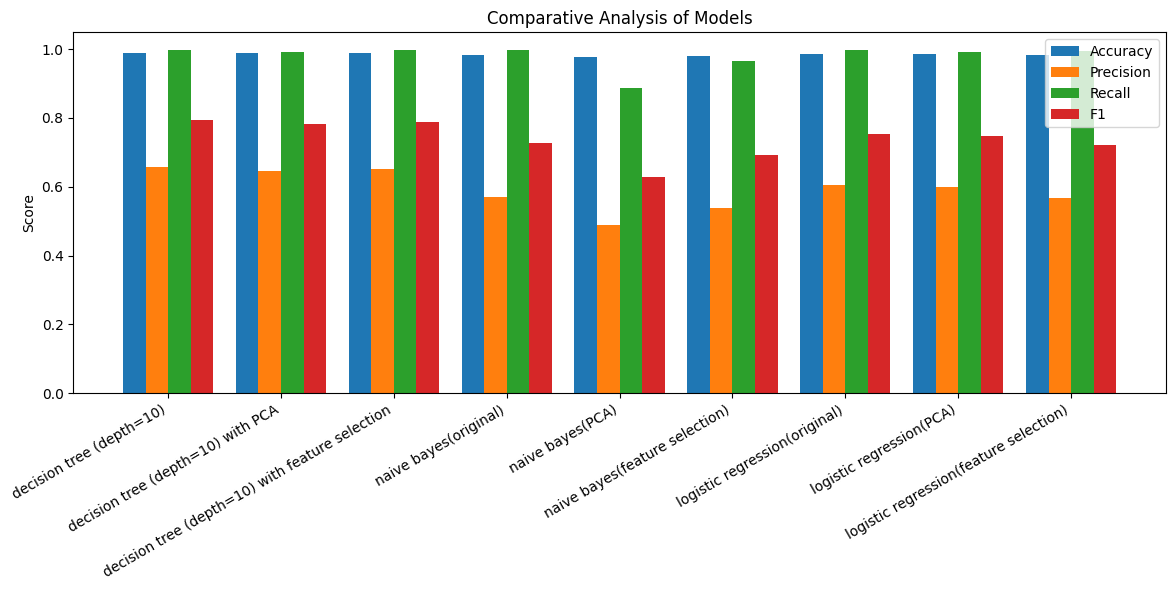

In [155]:
labels = list(model_results.keys())
values = np.array(list(model_results.values()))

# Metrics
accuracy = values[:,1]   # Test Accuracy
precision = values[:,3]  # Test Precision
recall = values[:,5]     # Test Recall
f1 = values[:,7]         # Test F1 Score

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1")

plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel("Score")
plt.title("Comparative Analysis of Models")
plt.legend()

plt.tight_layout()
plt.show()

In [158]:
# save everything

joblib.dump({'model': tree_fs, 'scaler': scaler, 'selector': selector, 'features': feature_names}, '/content/drive/MyDrive/Network_ids_model.pkl')

['/content/drive/MyDrive/Network_ids_model.pkl']

In [159]:
from google.colab import files
files.download('/content/drive/MyDrive/Network_ids_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>